<a href="https://colab.research.google.com/github/LourdesBranchi/camus-lv-segmentation/blob/main/notebooks/02_train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrenamiento en Google Colab — CAMUS Segmentación

**Antes de correr:** Menú → Runtime → Change runtime type → **GPU (T4)**

Este notebook entrena los dos modelos y genera los resultados comparativos.

## 0. Setup: GPU, Drive y repo

In [19]:
import sys
sys.path.insert(0, '/content/camus-lv-segmentation/src')

In [8]:
# Verificar GPU
import torch
print(f'GPU disponible: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU disponible: True
GPU: Tesla T4
Memoria: 15.6 GB


In [9]:
# Montar Google Drive (los checkpoints se guardan aquí para no perderlos)
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/camus_checkpoints'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Checkpoints se guardarán en: {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoints se guardarán en: /content/drive/MyDrive/camus_checkpoints


In [12]:
# Clonar el repo (reemplazar con tu URL)
TU_USUARIO = 'LourdesBranchi'
REPO_URL = f'https://github.com/{TU_USUARIO}/camus-lv-segmentation.git'
!git clone {REPO_URL}
%cd camus-lv-segmentation
!pip install -r requirements.txt -q

Cloning into 'camus-lv-segmentation'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 32 (delta 10), reused 26 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 31.97 KiB | 2.91 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/camus-lv-segmentation/camus-lv-segmentation


In [13]:
%cd /content

# Borrar todo
!rm -rf camus-lv-segmentation

# Clonar limpio
!git clone https://github.com/LourdesBranchi/camus-lv-segmentation.git

# Pararse en la carpeta correcta
%cd /content/camus-lv-segmentation

# Verificar que está bien
!ls

/content
Cloning into 'camus-lv-segmentation'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 32 (delta 10), reused 26 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 31.97 KiB | 3.55 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/camus-lv-segmentation
app  notebooks	README.md  requirements.txt  src


In [14]:
%cd /content/camus-lv-segmentation
!git pull

/content/camus-lv-segmentation
Already up to date.


## 1. Descargar dataset CAMUS desde Kaggle

In [15]:
# Borrar todo
!rm -rf dataset_raw
!rm -rf datos_corazon

In [16]:
# Configurar Kaggle API
# Instrucciones: https://www.kaggle.com/docs/api
# 1. Ir a kaggle.com → Account → API → Create New Token
# 2. Se descarga kaggle.json
# 3. En Colab: Secrets (🔑) → agregar KAGGLE_API_TOKEN con el contenido del json

from google.colab import userdata
import os, json

kaggle_token = userdata.get('KAGGLE_API_TOKEN')
os.environ['KAGGLE_CONFIG_DIR'] = '/root/.kaggle'
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_token)
!chmod 600 /root/.kaggle/kaggle.json

# Descargar y descomprimir
!kaggle datasets download -d shoybhasan/camus-human-heart-data -q
!unzip -q camus-human-heart-data.zip -d dataset_raw
!rm camus-human-heart-data.zip
print('Dataset descargado.')

Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
Dataset descargado.


In [17]:
# Descomprimir el archivo interno
import zipfile, os
inner = 'dataset_raw/download'
if os.path.exists(inner):
    with zipfile.ZipFile(inner, 'r') as z:
        z.extractall('datos_corazon')
    print('Dataset listo en: datos_corazon/')
    !ls datos_corazon/ | head -5
else:
    print('Buscar el archivo comprimido interno:')
    !find dataset_raw -name '*.zip' -o -name 'download'

Dataset listo en: datos_corazon/
database_nifti


## 2. EDA rápido

Pacientes encontrados: 500
Imágenes totales:      2000

División de pacientes:
  Train: 350 pacientes
  Val:   75 pacientes
  Test:  75 pacientes

Pares imagen/máscara:
  Train: 1400
  Val:   300
  Test:  300


/content/camus-lv-segmentation/src/dataset.py:61: UserWarning: Argument(s) 'std_limit' are not valid for transform GaussNoise
  A.GaussNoise(std_limit=(3.16, 7.07), p=0.3),


Batch imágenes: torch.Size([8, 1, 256, 256])  dtype=torch.float32
Batch máscaras: torch.Size([8, 256, 256])  clases=[0, 1, 2, 3]


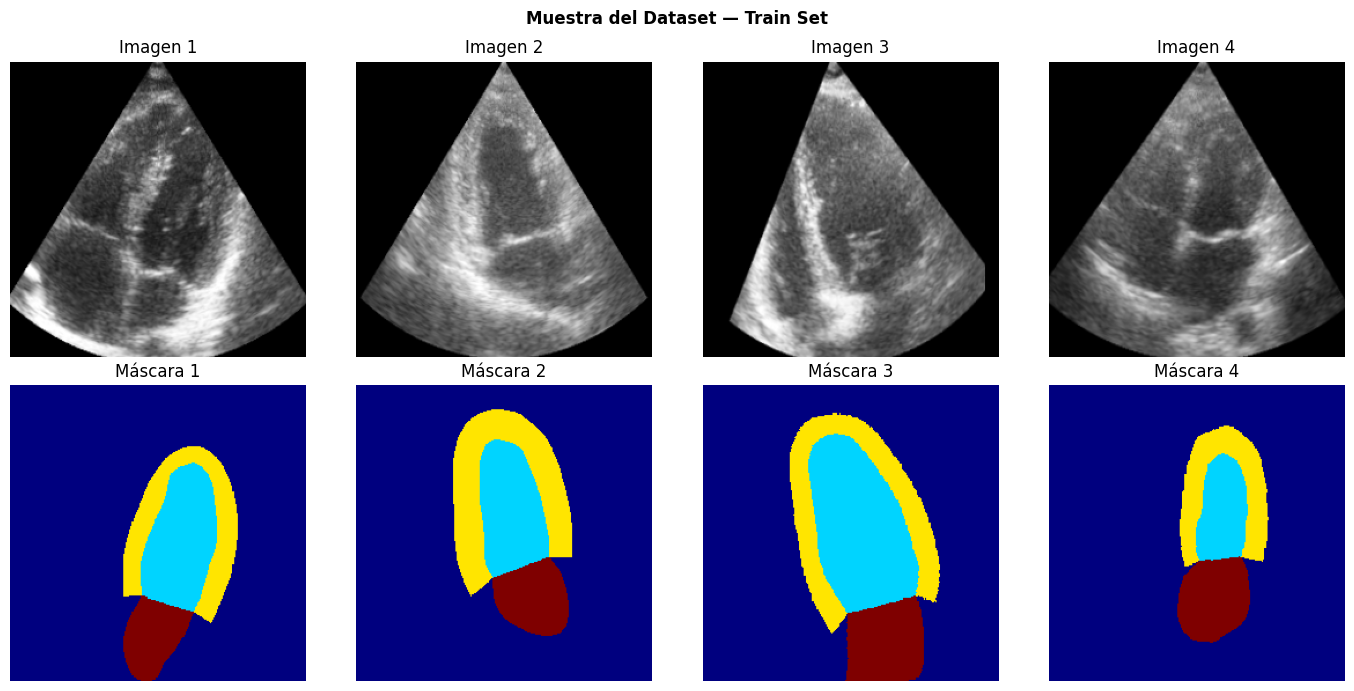

In [20]:
import sys
sys.path.insert(0, 'src')
from dataset import prepare_dataset

loaders = prepare_dataset(
    data_root='datos_corazon',
    batch_size=8,
    num_workers=2,
)

# Mostrar un batch de ejemplo
import matplotlib.pyplot as plt
import numpy as np

imgs, masks = next(iter(loaders['train']))
print(f'Batch imágenes: {imgs.shape}  dtype={imgs.dtype}')
print(f'Batch máscaras: {masks.shape}  clases={masks.unique().tolist()}')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(imgs[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title(f'Imagen {i+1}'); axes[0, i].axis('off')
    axes[1, i].imshow(masks[i].numpy(), cmap='jet', vmin=0, vmax=3)
    axes[1, i].set_title(f'Máscara {i+1}'); axes[1, i].axis('off')
plt.suptitle('Muestra del Dataset — Train Set', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Entrenar Modelo 1: U-Net + ResNet34

In [21]:
from train import train, DEFAULT_CONFIG

config_unet = {**DEFAULT_CONFIG,
    'model':      'unet',
    'encoder':    'resnet34',
    'epochs':     50,
    'batch_size': 8,
    'lr':         1e-4,
    'patience':   10,
    'data_root':  'datos_corazon',
    'save_dir':   DRIVE_DIR,    # guardar en Drive
    'device':     'cuda',
}

history_unet = train(config_unet)

Modelo:   unet + resnet34
Device:   cuda
Épocas:   50
Batch:    8
LR:       0.0001

Cargando dataset...
Pacientes encontrados: 500
Imágenes totales:      2000

División de pacientes:
  Train: 350 pacientes
  Val:   75 pacientes
  Test:  75 pacientes

Pares imagen/máscara:
  Train: 1400
  Val:   300
  Test:  300

Creando modelo...


/content/camus-lv-segmentation/src/dataset.py:61: UserWarning: Argument(s) 'std_limit' are not valid for transform GaussNoise
  A.GaussNoise(std_limit=(3.16, 7.07), p=0.3),
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

U-Net (resnet34, ImageNet) — 24.4M parámetros

Entrenando por 50 épocas...

Época [  1/50] (39s) lr=1.00e-04
  Train  loss=0.6556  dice=0.6733  [LV=0.771 MYO=0.653 LA=0.596]
  Val    loss=0.3647  dice=0.8544  [LV=0.907 MYO=0.808 LA=0.849]
  ✓ Mejor modelo guardado (val_dice=0.8544)

Época [  2/50] (38s) lr=1.00e-04
  Train  loss=0.2727  dice=0.8611  [LV=0.906 MYO=0.813 LA=0.865]
  Val    loss=0.1909  dice=0.8897  [LV=0.924 MYO=0.852 LA=0.893]
  ✓ Mejor modelo guardado (val_dice=0.8897)

Época [  3/50] (46s) lr=1.00e-04
  Train  loss=0.1707  dice=0.8807  [LV=0.919 MYO=0.837 LA=0.886]
  Val    loss=0.1418  dice=0.8924  [LV=0.927 MYO=0.850 LA=0.900]
  ✓ Mejor modelo guardado (val_dice=0.8924)

Época [  4/50] (46s) lr=1.00e-04
  Train  loss=0.1376  dice=0.8867  [LV=0.923 MYO=0.845 LA=0.892]
  Val    loss=0.1215  dice=0.8974  [LV=0.930 MYO=0.858 LA=0.904]
  ✓ Mejor modelo guardado (val_dice=0.8974)

Época [  5/50] (45s) lr=1.00e-04
  Train  loss=0.1174  dice=0.8958  [LV=0.929 MYO=0.856 LA=0

## 4. Entrenar Modelo 2: Attention U-Net + EfficientNet-B0

In [22]:
config_attn = {**DEFAULT_CONFIG,
    'model':      'attention-unet',
    'encoder':    'efficientnet-b0',
    'epochs':     50,
    'batch_size': 8,
    'lr':         1e-4,
    'patience':   10,
    'data_root':  'datos_corazon',
    'save_dir':   DRIVE_DIR,
    'device':     'cuda',
}

history_attn = train(config_attn)

Modelo:   attention-unet + efficientnet-b0
Device:   cuda
Épocas:   50
Batch:    8
LR:       0.0001

Cargando dataset...
Pacientes encontrados: 500
Imágenes totales:      2000

División de pacientes:
  Train: 350 pacientes
  Val:   75 pacientes
  Test:  75 pacientes

Pares imagen/máscara:
  Train: 1400
  Val:   300
  Test:  300

Creando modelo...


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Attention U-Net (efficientnet-b0, ImageNet) — 6.3M parámetros

Entrenando por 50 épocas...

Época [  1/50] (42s) lr=1.00e-04
  Train  loss=0.7299  dice=0.5045  [LV=0.638 MYO=0.515 LA=0.360]
  Val    loss=0.8221  dice=0.0050  [LV=0.000 MYO=0.000 LA=0.015]
  ✓ Mejor modelo guardado (val_dice=0.0050)

Época [  2/50] (42s) lr=1.00e-04
  Train  loss=0.2942  dice=0.8247  [LV=0.889 MYO=0.762 LA=0.824]
  Val    loss=0.8947  dice=0.0001  [LV=0.000 MYO=0.000 LA=0.000]

Época [  3/50] (43s) lr=1.00e-04
  Train  loss=0.1844  dice=0.8623  [LV=0.909 MYO=0.814 LA=0.864]
  Val    loss=0.3824  dice=0.5847  [LV=0.548 MYO=0.626 LA=0.580]
  ✓ Mejor modelo guardado (val_dice=0.5847)

Época [  4/50] (44s) lr=1.00e-04
  Train  loss=0.1478  dice=0.8722  [LV=0.914 MYO=0.828 LA=0.875]
  Val    loss=0.2208  dice=0.7897  [LV=0.813 MYO=0.766 LA=0.791]
  ✓ Mejor modelo guardado (val_dice=0.7897)

Época [  5/50] (43s) lr=1.00e-04
  Train  loss=0.1307  dice=0.8780  [LV=0.917 MYO=0.835 LA=0.881]
  Val    loss=0.1210  

## 5. Curvas de entrenamiento

In [23]:
from evaluate import plot_training_history

plot_training_history(history_unet,  'U-Net + ResNet34',              'unet_history.png')
plot_training_history(history_attn,  'Attention U-Net + EfficientNet-B0', 'attn_history.png')

Historial guardado en: unet_history.png
Historial guardado en: attn_history.png


## 6. Evaluación en Test Set

In [24]:
import torch
from models   import get_model
from losses   import CombinedLoss
from evaluate import evaluate, print_metrics_table, visualize_predictions, compare_models

device  = torch.device('cuda')
loss_fn = CombinedLoss()
results = {}

# Evaluar U-Net
ckpt1 = torch.load(f'{DRIVE_DIR}/best_unet_resnet34.pth', map_location=device)
m1    = get_model('unet', encoder_name='resnet34').to(device)
m1.load_state_dict(ckpt1['model_state'])
r1    = evaluate(m1, loaders['test'], loss_fn, device, 'U-Net')
print_metrics_table(r1, 'U-Net + ResNet34')
results['U-Net + ResNet34'] = r1

# Visualizaciones U-Net
visualize_predictions(m1, loaders['test'], device,
                      n_samples=6, save_path='predictions_unet.png',
                      model_name='U-Net + ResNet34')

# Evaluar Attention U-Net
ckpt2 = torch.load(f'{DRIVE_DIR}/best_attention-unet_efficientnet-b0.pth', map_location=device)
m2    = get_model('attention-unet', encoder_name='efficientnet-b0').to(device)
m2.load_state_dict(ckpt2['model_state'])
r2    = evaluate(m2, loaders['test'], loss_fn, device, 'Attention U-Net')
print_metrics_table(r2, 'Attention U-Net + EfficientNet-B0')
results['Attention U-Net + EfficientNet-B0'] = r2

# Visualizaciones Attention U-Net
visualize_predictions(m2, loaders['test'], device,
                      n_samples=6, save_path='predictions_attn.png',
                      model_name='Attention U-Net + EfficientNet-B0')

U-Net (resnet34, ImageNet) — 24.4M parámetros



  Resultados en Test Set — U-Net + ResNet34
  Métrica                        Valor
  -----------------------------------
  Loss                          0.1094
  -----------------------------------
  Mean Dice (cardíaco)          0.9082
  Dice LV                       0.9382
  Dice MYO                      0.8758
  Dice LA                       0.9104
  -----------------------------------
  Mean IoU (cardíaco)           0.8338
  IoU LV                        0.8842
  IoU MYO                       0.7798
  IoU LA                        0.8374



Visualización guardada en: predictions_unet.png
Attention U-Net (efficientnet-b0, ImageNet) — 6.3M parámetros



  Resultados en Test Set — Attention U-Net + EfficientNet-B0
  Métrica                        Valor
  -----------------------------------
  Loss                          0.0966
  -----------------------------------
  Mean Dice (cardíaco)          0.9044
  Dice LV                       0.9376
  Dice MYO                      0.8720
  Dice LA                       0.9036
  -----------------------------------
  Mean IoU (cardíaco)           0.8281
  IoU LV                        0.8829
  IoU MYO                       0.7739
  IoU LA                        0.8275



Visualización guardada en: predictions_attn.png


## 7. Comparativa final entre modelos

In [25]:
compare_models(results, save_path='comparativa_modelos.png')

# Tabla resumen
print('\n' + '='*65)
print(f'{"Modelo":<40} {"LV":>6} {"MYO":>6} {"LA":>6} {"Mean":>6}')
print('='*65)
for name, m in results.items():
    print(f'{name:<40} {m["dice_lv"]:>6.3f} {m["dice_myo"]:>6.3f} {m["dice_la"]:>6.3f} {m["mean_dice_cardiac"]:>6.3f}')
print(f'{"Referencia (Leclerc 2019)":<40} {0.94:>6.3f} {0.85:>6.3f} {0.89:>6.3f} {0.89:>6.3f}')
print('='*65)

Comparativa guardada en: comparativa_modelos.png

Modelo                                       LV    MYO     LA   Mean
U-Net + ResNet34                          0.938  0.876  0.910  0.908
Attention U-Net + EfficientNet-B0         0.938  0.872  0.904  0.904
Referencia (Leclerc 2019)                 0.940  0.850  0.890  0.890


## 8. Descargar resultados

Copiar los archivos generados a Drive para no perderlos.

In [26]:
import shutil
archivos = ['predictions_unet.png', 'predictions_attn.png',
            'comparativa_modelos.png', 'unet_history.png', 'attn_history.png']

for f in archivos:
    if os.path.exists(f):
        shutil.copy(f, DRIVE_DIR)
        print(f'Copiado: {f} → {DRIVE_DIR}')

print('\n✓ Todos los resultados guardados en Google Drive')

Copiado: predictions_unet.png → /content/drive/MyDrive/camus_checkpoints
Copiado: predictions_attn.png → /content/drive/MyDrive/camus_checkpoints
Copiado: comparativa_modelos.png → /content/drive/MyDrive/camus_checkpoints
Copiado: unet_history.png → /content/drive/MyDrive/camus_checkpoints
Copiado: attn_history.png → /content/drive/MyDrive/camus_checkpoints

✓ Todos los resultados guardados en Google Drive


In [27]:
import json

# Guardar history del Modelo 1
with open('/content/drive/MyDrive/camus_checkpoints/history_unet_resnet34.json', 'w') as f:
    json.dump(history_unet, f)

# Guardar history del Modelo 2 (cuando termine)
with open('/content/drive/MyDrive/camus_checkpoints/history_attn_efficientnet.json', 'w') as f:
    json.dump(history_attn, f)

print("Histories guardados en Drive.")

Histories guardados en Drive.
